In [ ]:
import kagglehub
import os


path = kagglehub.dataset_download("snehilsanyal/weapon-detection-test")
print(f"Dataset path: {path}")


data_path = os.path.join(path, "weapon_detection")
train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "val")
test_path = os.path.join(path, "test", "test")

print(f"Train: {train_path}")
print(f"Val: {val_path}")
print(f"Test: {test_path}")

100%|██████████| 194M/194M [00:01<00:00, 120MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5
Train: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/weapon_detection/train
Val: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/weapon_detection/val
Test: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/test/test


Total Images: Train=571, Val=143, Test=8
Classes: ['Class_0', 'Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8']
   Class_5: 108 instances
   Class_0: 726 instances
   Class_2: 88 instances
   Class_1: 12 instances
   Class_4: 2 instances


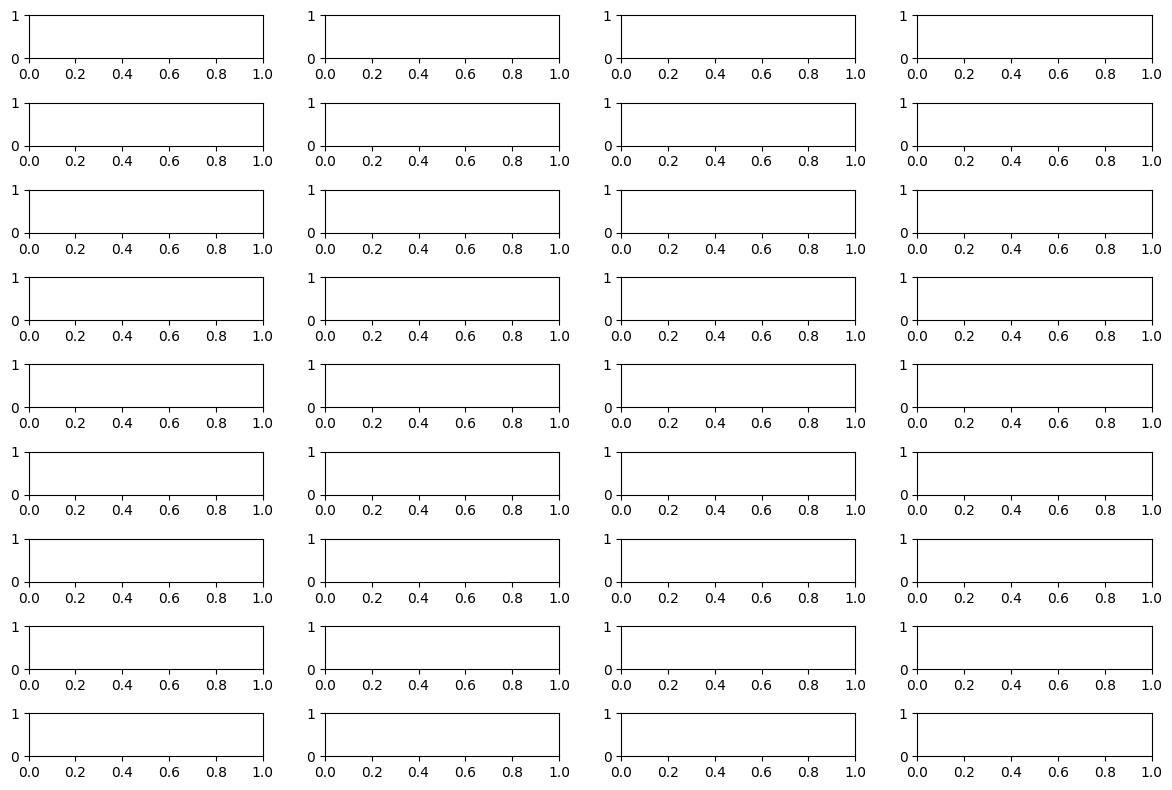

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt


train_imgs = len(os.listdir(os.path.join(train_path, "images")))
val_imgs = len(os.listdir(os.path.join(val_path, "images")))
test_imgs = len(os.listdir(test_path)) if os.path.exists(test_path) else 0

print(f"Total Images: Train={train_imgs}, Val={val_imgs}, Test={test_imgs}")

# Step 2: Class Names (from metadata)
import pandas as pd
metadata = pd.read_csv(os.path.join(path, "metadata.csv"))


unique_targets = sorted(metadata['target'].unique())
classes = [f"Class_{tid}" for tid in unique_targets]

print(f"Classes: {classes}")

from collections import Counter
class_counts = Counter()

for label_file in os.listdir(os.path.join(train_path, "labels")):
    if label_file.endswith('.txt'):
        with open(os.path.join(train_path, "labels", label_file), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

for cls_id, count in class_counts.items():
    print(f"   {classes[cls_id]}: {count} instances")


import cv2
import numpy as np

def visualize_samples(train_path, classes, num_samples=4):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 8))

    for i, cls_name in enumerate(classes):
        cls_id = i

        img_files = []
        for label_file in os.listdir(os.path.join(train_path, "labels"))[:100]:
            with open(os.path.join(train_path, "labels", label_file), 'r') as f:
                if any(int(line.split()[0]) == cls_id for line in f):
                    img_name = label_file.replace('.txt', '.jpg')
                    if os.path.exists(os.path.join(train_path, "images", img_name)):
                        img_files.append(img_name)


        for j in range(min(num_samples, len(img_files))):
            img = cv2.imread(os.path.join(train_path, "images", img_files[j]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls_name}")
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(train_path, classes)


In [ ]:
# Phase 4: Class Imbalance Check
total_instances = sum(class_counts.values())
print("\nClass Distribution:")
for cls_id, count in class_counts.items():
    percentage = (count / total_instances) * 100
    print(f"   {classes[cls_id]}: {count} instances ({percentage:.1f}%)")

# Imbalance Ratio
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}")




Class Distribution:
   Class_5: 108 instances (11.5%)
   Class_0: 726 instances (77.6%)
   Class_2: 88 instances (9.4%)
   Class_1: 12 instances (1.3%)
   Class_4: 2 instances (0.2%)

 Imbalance Ratio: 363.00


In [ ]:
# Create data.yaml for YOLOv8
yaml_content = f"""
# YOLOv8 Weapon Detection Dataset
path: {data_path}
train: train/images
val: val/images

# Classes
nc: {len(classes)}
names: {classes}
"""

with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_content)

In [ ]:
# Install YOLOv8
!pip install ultralytics

from ultralytics import YOLO

# Load pretrained model
model = YOLO('yolov8m.pt')  # medium size (balanced)

# Train
results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='weapon_detector',
    patience=10,
    device=0,  # GPU
    plots=True,  # Auto-generate all graphs
    save=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0